# PTB-XL ST-GNN

This notebook reuses the PTB-XL loading, SCP superclass label extraction, preprocessing, and official stratified folds from `ptbxl_1dcnn.ipynb`, then replaces the 1D CNN with a spatio-temporal graph neural network.

The model treats the 12 ECG leads as graph nodes. Temporal gated convolutions learn morphology over time, while graph convolutions mix information across anatomically related leads.

In [1]:
# Install dependencies if needed.
%pip install wfdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 798.6 kB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, ast, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import wfdb

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report,
    multilabel_confusion_matrix, average_precision_score, roc_curve
)
from sklearn.preprocessing import StandardScaler

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


In [3]:
# Paths
DATA_DIR = '/kaggle/input/datasets/khyeh0719/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1'
DB_CSV = os.path.join(DATA_DIR, 'ptbxl_database.csv')
SCP_CSV = os.path.join(DATA_DIR, 'scp_statements.csv')

# Signal settings
SAMPLING_RATE = 100  # 100 or 500
N_LEADS = 12
SEQ_LEN = 1000 if SAMPLING_RATE == 100 else 5000

# Label settings
SUPERCLASSES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
N_CLASSES = len(SUPERCLASSES)

# Training
BATCH_SIZE = 32
EPOCHS = 15
LR = 5e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 15
DROPOUT = 0.25

# Checkpoint
CKPT_PATH = 'best_stgnn.pt'

## Metadata And Labels

This section is intentionally kept close to the 1D CNN notebook: read PTB-XL metadata, parse SCP dictionaries, keep diagnostic SCP statements, and map them to the five official diagnostic superclasses.

In [4]:
df = pd.read_csv(DB_CSV, index_col='ecg_id')
df.scp_codes = df.scp_codes.apply(ast.literal_eval)

scp = pd.read_csv(SCP_CSV, index_col=0)
scp_diag = scp[scp.diagnostic == 1].copy()

print(f'Total records: {len(df):,}')
print(f'Diagnostic SCP codes: {len(scp_diag)}')
df.head(3)

Total records: 21,837
Diagnostic SCP codes: 44


,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr


In [5]:
def map_to_superclass(scp_codes: dict) -> list:
    labels = set()
    for code_name, likelihood in scp_codes.items():
        if code_name in scp_diag.index:
            superclass = scp_diag.loc[code_name, 'diagnostic_class']
            if isinstance(superclass, str) and superclass in SUPERCLASSES:
                labels.add(superclass)
    return sorted(labels)


df['superclass'] = df.scp_codes.apply(map_to_superclass)
df = df[df.superclass.map(len) > 0].copy()

for superclass in SUPERCLASSES:
    df[superclass] = df.superclass.apply(lambda labels: int(superclass in labels))

print(f'Records with at least one superclass label: {len(df):,}')
print('\nLabel distribution:')
print(df[SUPERCLASSES].sum().rename('count').to_frame())

Records with at least one superclass label: 21,430

Label distribution:
      count
NORM   9528
MI     5486
STTC   5250
CD     4907
HYP    2655


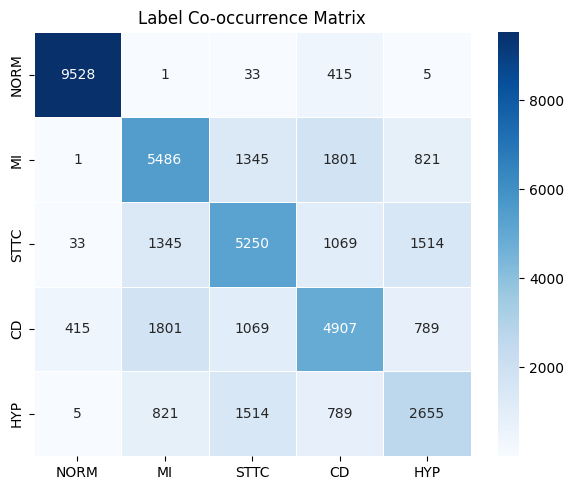

In [6]:
co = df[SUPERCLASSES].T.dot(df[SUPERCLASSES])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(co, annot=True, fmt='d', cmap='Blues', linewidths=.5, ax=ax)
ax.set_title('Label Co-occurrence Matrix')
plt.tight_layout()
plt.show()

## Official Folds

PTB-XL provides `strat_fold`. The usual setup is folds 1-8 for training, fold 9 for validation, and fold 10 for test.

In [7]:
train_df = df[df.strat_fold <= 8].copy()
val_df = df[df.strat_fold == 9].copy()
test_df = df[df.strat_fold == 10].copy()

print(f'Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')

pos = train_df[SUPERCLASSES].sum().values
neg = len(train_df) - pos
pos_weight = torch.tensor(neg / np.maximum(pos, 1), dtype=torch.float32).to(DEVICE)
pos_weight = pos_weight ** 1.2  # Add power scaling to boost minority classes more

print('\nPos weights (neg/pos per class):')
for superclass, weight in zip(SUPERCLASSES, pos_weight.cpu()):
    print(f'  {superclass}: {weight:.2f}')

Train: 17,111 | Val: 2,156 | Test: 2,163

Pos weights (neg/pos per class):
  NORM: 1.31
  MI: 3.59
  STTC: 3.86
  CD: 4.30
  HYP: 10.45


## Lead Graph

The graph is a small fixed prior over the 12 ECG leads. It connects limb leads, chains adjacent precordial leads, and adds a few limb-to-precordial links. The model can still learn temporal morphology through convolutional filters; this adjacency only controls spatial message passing between leads.

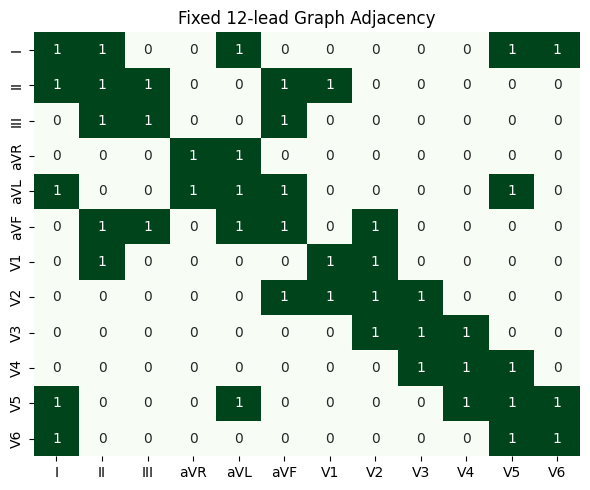

In [8]:
LEAD_NAMES = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
LEAD_TO_IDX = {lead: i for i, lead in enumerate(LEAD_NAMES)}


def build_lead_adjacency() -> torch.Tensor:
    edges = [
        # Limb-lead relationships
        ('I', 'II'), ('I', 'aVL'), ('II', 'III'), ('II', 'aVF'),
        ('III', 'aVF'), ('aVR', 'aVL'), ('aVL', 'aVF'),
        # Precordial spatial chain
        ('V1', 'V2'), ('V2', 'V3'), ('V3', 'V4'), ('V4', 'V5'), ('V5', 'V6'),
        # Cross-region links
        ('I', 'V5'), ('I', 'V6'), ('aVL', 'V5'), ('II', 'V1'), ('aVF', 'V2'),
    ]
    adj = torch.eye(N_LEADS, dtype=torch.float32)
    for left, right in edges:
        i, j = LEAD_TO_IDX[left], LEAD_TO_IDX[right]
        adj[i, j] = 1.0
        adj[j, i] = 1.0
    return adj


def normalize_adjacency(adj: torch.Tensor) -> torch.Tensor:
    degree = adj.sum(dim=1)
    inv_sqrt_degree = torch.pow(degree.clamp_min(1.0), -0.5)
    d_inv_sqrt = torch.diag(inv_sqrt_degree)
    return d_inv_sqrt @ adj @ d_inv_sqrt


ADJ = build_lead_adjacency()
ADJ_NORM = normalize_adjacency(ADJ)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(ADJ.numpy(), annot=True, fmt='.0f', cmap='Greens', cbar=False,
            xticklabels=LEAD_NAMES, yticklabels=LEAD_NAMES, ax=ax)
ax.set_title('Fixed 12-lead Graph Adjacency')
plt.tight_layout()
plt.show()

## Dataset And Preprocessing

Signals are read from WFDB on demand. The returned tensor shape is `(12, T)`, where the 12 rows are graph nodes and `T` is the temporal axis.

In [9]:
class PTBXLDataset(Dataset):
    def __init__(self, dataframe, data_dir, sampling_rate=100, scaler=None, augment=False):
        self.df = dataframe.reset_index(drop=False)
        self.root = data_dir
        self.sr = sampling_rate
        self.scaler = scaler
        self.augment = augment
        self.fn_col = 'filename_lr' if sampling_rate == 100 else 'filename_hr'
        self.expected_len = 1000 if sampling_rate == 100 else 5000

    def __len__(self):
        return len(self.df)

    def _load_signal(self, idx):
        row = self.df.iloc[idx]
        path = os.path.join(self.root, row[self.fn_col])
        sig, _ = wfdb.rdsamp(path)
        sig = sig.astype(np.float32)
        if sig.shape[0] != self.expected_len:
            sig = self._pad_or_crop(sig, self.expected_len)
        return sig

    @staticmethod
    def _pad_or_crop(sig, target_len):
        if sig.shape[0] > target_len:
            start = (sig.shape[0] - target_len) // 2
            return sig[start:start + target_len]
        pad = target_len - sig.shape[0]
        left = pad // 2
        right = pad - left
        return np.pad(sig, ((left, right), (0, 0)), mode='constant')

    @staticmethod
    def _add_gaussian_noise(sig, std=0.02):
        return sig + np.random.randn(*sig.shape).astype(np.float32) * std

    @staticmethod
    def _random_scale(sig, low=0.85, high=1.15):
        scale = np.random.uniform(low, high, size=(1, sig.shape[1])).astype(np.float32)
        return sig * scale

    @staticmethod
    def _random_shift(sig, max_shift=100):
        shift = np.random.randint(-max_shift, max_shift + 1)
        return np.roll(sig, shift, axis=0)

    def __getitem__(self, idx):
        sig = self._load_signal(idx)  # (T, 12)

        if self.scaler is not None:
            sig = self.scaler.transform(sig).astype(np.float32)
        else:
            sig = ((sig - sig.mean(axis=0)) / (sig.std(axis=0) + 1e-8)).astype(np.float32)

        if self.augment:
            if np.random.rand() < 0.5:
                sig = self._add_gaussian_noise(sig)
            if np.random.rand() < 0.5:
                sig = self._random_scale(sig)
            if np.random.rand() < 0.3:
                sig = self._random_shift(sig)

        sig = torch.tensor(sig.T.copy(), dtype=torch.float32)  # (12, T)
        row = self.df.iloc[idx]
        labels = torch.tensor(row[SUPERCLASSES].values.astype(np.float32))
        return sig, labels

In [10]:
USE_GLOBAL_SCALER = False
scaler = None

if USE_GLOBAL_SCALER:
    sample_size = min(2000, len(train_df))
    print(f'Fitting global scaler on a {sample_size:,}-record training sample...')
    sample_df = train_df.sample(sample_size, random_state=SEED)
    fn_col = 'filename_lr' if SAMPLING_RATE == 100 else 'filename_hr'
    signals = []
    for _, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
        sig, _ = wfdb.rdsamp(os.path.join(DATA_DIR, row[fn_col]))
        signals.append(sig.astype(np.float32))
    all_sig = np.concatenate(signals, axis=0)
    scaler = StandardScaler().fit(all_sig)
    print('Scaler fitted.')

train_ds = PTBXLDataset(train_df, DATA_DIR, SAMPLING_RATE, scaler, augment=True)
val_ds = PTBXLDataset(val_df, DATA_DIR, SAMPLING_RATE, scaler, augment=False)
test_ds = PTBXLDataset(test_df, DATA_DIR, SAMPLING_RATE, scaler, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=0, pin_memory=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=0, pin_memory=False)

print(f'Batches - train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}')
sig_b, lbl_b = next(iter(train_loader))
print(f'Signal batch: {sig_b.shape} | Labels batch: {lbl_b.shape}')

Batches - train: 535 | val: 68 | test: 68
Signal batch: torch.Size([32, 12, 1000]) | Labels batch: torch.Size([32, 5])


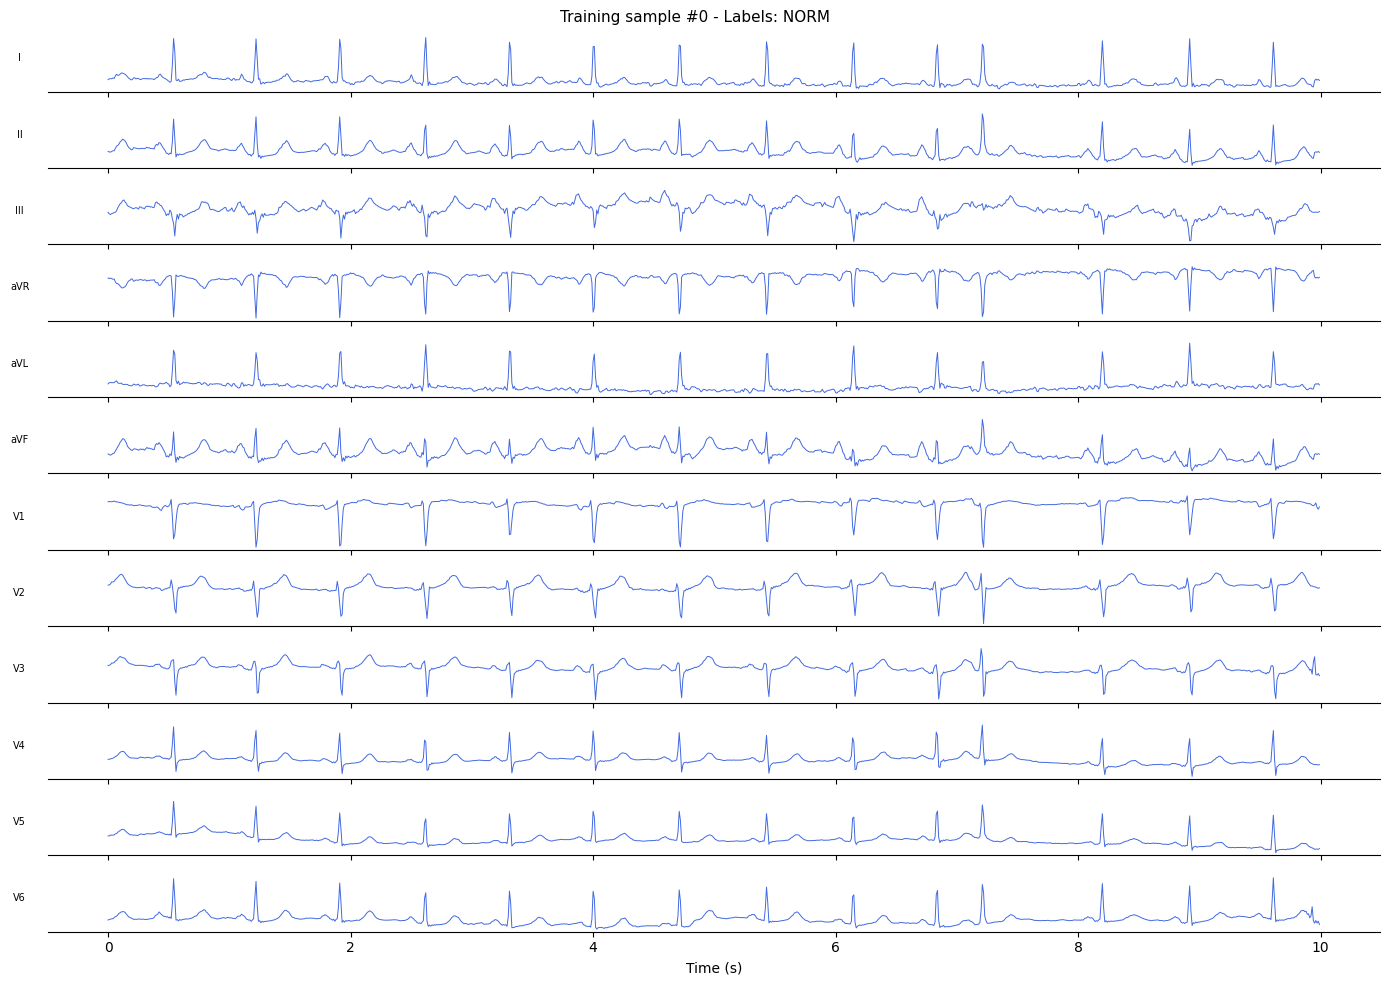

In [11]:
def plot_ecg(sig_tensor, label_tensor, title='ECG Sample'):
    sig = sig_tensor.numpy()
    labels = label_tensor.numpy()
    active = [SUPERCLASSES[i] for i, value in enumerate(labels) if value == 1]

    fig, axes = plt.subplots(12, 1, figsize=(14, 10), sharex=True)
    t = np.arange(sig.shape[1]) / SAMPLING_RATE
    for i, ax in enumerate(axes):
        ax.plot(t, sig[i], lw=0.7, color='royalblue')
        ax.set_ylabel(LEAD_NAMES[i], fontsize=7, rotation=0, labelpad=20)
        ax.set_yticks([])
        ax.spines[['top', 'right', 'left']].set_visible(False)
    axes[-1].set_xlabel('Time (s)')
    fig.suptitle(f'{title} - Labels: {", ".join(active)}', fontsize=11)
    plt.tight_layout()
    plt.show()

plot_ecg(sig_b[0], lbl_b[0], title='Training sample #0')

## ST-GNN Model

Input shape is `(batch, 12, T)`. The model expands this to `(batch, channels, nodes, time)`, alternates temporal gated convolutions with graph convolutions over the lead graph, then pools across nodes and time for multi-label classification.

In [12]:
class TemporalGatedConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=9):
        super().__init__()
        padding = kernel_size // 2
        self.conv = nn.Conv2d(
            in_channels,
            out_channels * 2,
            kernel_size=(1, kernel_size),
            padding=(0, padding),
        )

    def forward(self, x):
        value, gate = self.conv(x).chunk(2, dim=1)
        return value * torch.sigmoid(gate)


class GraphConv(nn.Module):
    def __init__(self, in_channels, out_channels, adj_norm):
        super().__init__()
        self.register_buffer('adj_norm', adj_norm.clone().float())
        self.self_proj = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.neigh_proj = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bias = nn.Parameter(torch.zeros(out_channels))

    def forward(self, x):
        neigh = torch.einsum('ij,bcjt->bcit', self.adj_norm, x)
        out = self.self_proj(x) + self.neigh_proj(neigh)
        return out + self.bias.view(1, -1, 1, 1)


class STGNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, adj_norm, kernel_size=9, dropout=0.25):
        super().__init__()
        self.temporal1 = TemporalGatedConv(in_channels, out_channels, kernel_size)
        self.graph = GraphConv(out_channels, out_channels, adj_norm)
        self.norm1 = nn.BatchNorm2d(out_channels)
        self.temporal2 = TemporalGatedConv(out_channels, out_channels, kernel_size)
        self.norm2 = nn.BatchNorm2d(out_channels)
        self.dropout = nn.Dropout(dropout)
        self.residual = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()

    def forward(self, x):
        residual = self.residual(x)
        x = self.temporal1(x)
        x = F.relu(self.graph(x))
        x = self.norm1(x)
        x = self.dropout(x)
        x = self.temporal2(x)
        x = self.norm2(x)
        x = self.dropout(x)
        return F.relu(x + residual)


class ECGSTGNN(nn.Module):
    def __init__(self, adj_norm, n_classes=5, dropout=0.25):
        super().__init__()
        self.blocks = nn.Sequential(
            STGNNBlock(1, 32, adj_norm, kernel_size=15, dropout=dropout),
            STGNNBlock(32, 64, adj_norm, kernel_size=11, dropout=dropout),
            STGNNBlock(64, 96, adj_norm, kernel_size=7, dropout=dropout),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(96, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        x = x.unsqueeze(1)  # (B, 1, 12, T)
        x = self.blocks(x)
        x = self.pool(x)
        return self.classifier(x)


model = ECGSTGNN(ADJ_NORM, n_classes=N_CLASSES, dropout=DROPOUT).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params:,}')

with torch.no_grad():
    dummy = torch.randn(2, N_LEADS, SEQ_LEN).to(DEVICE)
    out = model(dummy)
    print(f'Output shape: {out.shape} (expected (2, {N_CLASSES}))')

Trainable parameters: 427,237
Output shape: torch.Size([2, 5]) (expected (2, 5))


## Training

In [ ]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimiser = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimiser,
    max_lr=LR,
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS,
    pct_start=0.1,
    anneal_strategy='cos',
)

scaler_amp = GradScaler(enabled=(DEVICE.type == 'cuda'))

In [14]:
def run_epoch(loader, model, criterion, optimiser=None, scaler_amp=None, scheduler=None, desc='train'):
    training = optimiser is not None
    model.train(training)

    total_loss = 0.0
    all_logits, all_labels = [], []

    pbar = tqdm(loader, desc=desc, leave=False)
    for sigs, labels in pbar:
        sigs = sigs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with autocast(enabled=(DEVICE.type == 'cuda')):
            logits = model(sigs)
            loss = criterion(logits, labels)

        if training:
            optimiser.zero_grad(set_to_none=True)
            scaler_amp.scale(loss).backward()
            scaler_amp.unscale_(optimiser)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler_amp.step(optimiser)
            scaler_amp.update()
            if scheduler is not None:
                scheduler.step()

        total_loss += loss.item() * sigs.size(0)
        all_logits.append(logits.detach().cpu().numpy())
        all_labels.append(labels.detach().cpu().numpy())
        pbar.set_postfix(loss=f'{loss.item():.4f}')

    avg_loss = total_loss / len(loader.dataset)
    all_logits = np.concatenate(all_logits, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    return avg_loss, all_logits, all_labels


def sigmoid_np(logits):
    return 1 / (1 + np.exp(-logits))


def macro_auc(logits, labels):
    probs = sigmoid_np(logits)
    valid = (labels.sum(axis=0) > 0) & (labels.sum(axis=0) < labels.shape[0])
    return roc_auc_score(labels[:, valid], probs[:, valid], average='macro')

In [15]:
history = dict(train_loss=[], val_loss=[], train_auc=[], val_auc=[])
best_val_auc = 0.0
patience_ctr = 0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_logits, tr_labels = run_epoch(
        train_loader, model, criterion, optimiser,
        scaler_amp, scheduler, desc=f'[{epoch:02d}/{EPOCHS}] train'
    )

    with torch.no_grad():
        vl_loss, vl_logits, vl_labels = run_epoch(
            val_loader, model, criterion, desc=f'[{epoch:02d}/{EPOCHS}] val'
        )

    tr_auc = macro_auc(tr_logits, tr_labels)
    vl_auc = macro_auc(vl_logits, vl_labels)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_auc'].append(tr_auc)
    history['val_auc'].append(vl_auc)

    print(f'Epoch {epoch:02d} '
          f'Train loss {tr_loss:.4f} AUC {tr_auc:.4f} | '
          f'Val loss {vl_loss:.4f} AUC {vl_auc:.4f}')

    if vl_auc > best_val_auc:
        best_val_auc = vl_auc
        torch.save(model.state_dict(), CKPT_PATH)
        print(f'  New best val AUC: {best_val_auc:.4f} - checkpoint saved.')
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f'Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs).')
            break

print(f'\nTraining complete. Best val AUC: {best_val_auc:.4f}')

[01/15] train:   0%|          | 0/535 [00:00<?, ?it/s]

[01/15] val:   0%|          | 0/68 [00:00<?, ?it/s]

Epoch 01 Train loss 0.9714 AUC 0.7755 | Val loss 0.8129 AUC 0.8535
  New best val AUC: 0.8535 - checkpoint saved.


[02/15] train:   0%|          | 0/535 [00:00<?, ?it/s]

[02/15] val:   0%|          | 0/68 [00:00<?, ?it/s]

...

[14/15] val:   0%|          | 0/68 [00:00<?, ?it/s]

Epoch 14 Train loss 0.5430 AUC 0.9356 | Val loss 0.6774 AUC 0.9162
  New best val AUC: 0.9162 - checkpoint saved.


[15/15] train:   0%|          | 0/535 [00:00<?, ?it/s]

[15/15] val:   0%|          | 0/68 [00:00<?, ?it/s]

Epoch 15 Train loss 0.5419 AUC 0.9359 | Val loss 0.6781 AUC 0.9163
  New best val AUC: 0.9163 - checkpoint saved.

Training complete. Best val AUC: 0.9163


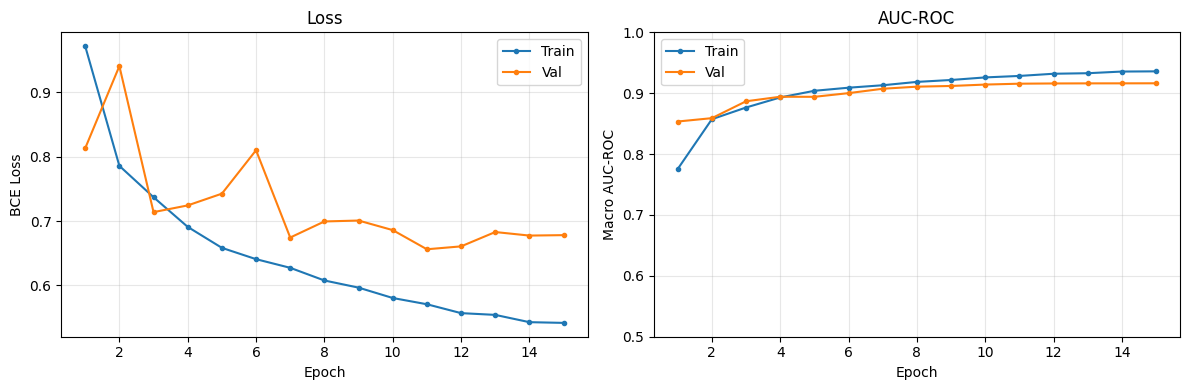

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, len(history['train_loss']) + 1)

ax1.plot(ep, history['train_loss'], label='Train', marker='.')
ax1.plot(ep, history['val_loss'], label='Val', marker='.')
ax1.set(xlabel='Epoch', ylabel='BCE Loss', title='Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep, history['train_auc'], label='Train', marker='.')
ax2.plot(ep, history['val_auc'], label='Val', marker='.')
ax2.set(xlabel='Epoch', ylabel='Macro AUC-ROC', title='AUC-ROC', ylim=(0.5, 1.0))
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Evaluation

In [17]:
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

with torch.no_grad():
    _, test_logits, test_labels = run_epoch(test_loader, model, criterion, desc='test')

test_probs = sigmoid_np(test_logits)

print('=== Per-class AUC-ROC ===')
auc_per_class = roc_auc_score(test_labels, test_probs, average=None)
for superclass, auc in zip(SUPERCLASSES, auc_per_class):
    print(f'  {superclass:6s}: {auc:.4f}')
print(f'  {"MACRO":6s}: {auc_per_class.mean():.4f}')

print('\n=== Per-class Average Precision (AP) ===')
ap_per_class = average_precision_score(test_labels, test_probs, average=None)
for superclass, ap in zip(SUPERCLASSES, ap_per_class):
    print(f'  {superclass:6s}: {ap:.4f}')
print(f'  {"MACRO":6s}: {ap_per_class.mean():.4f}')

test:   0%|          | 0/68 [00:00<?, ?it/s]

=== Per-class AUC-ROC ===
  NORM  : 0.9363
  MI    : 0.9235
  STTC  : 0.9299
  CD    : 0.9231
  HYP   : 0.8401
  MACRO : 0.9106

=== Per-class Average Precision (AP) ===
  NORM  : 0.9067
  MI    : 0.8201
  STTC  : 0.8179
  CD    : 0.8434
  HYP   : 0.5234
  MACRO : 0.7823


In [18]:
model.eval()
with torch.no_grad():
    _, val_logits, val_labels = run_epoch(val_loader, model, criterion, desc='val-thresh')
val_probs = sigmoid_np(val_logits)

thresholds = np.arange(0.1, 0.9, 0.02)
best_thresh = np.zeros(N_CLASSES)

for c in range(N_CLASSES):
    best_f1, best_t = 0.0, 0.5
    for threshold in thresholds:
        preds = (val_probs[:, c] >= threshold).astype(int)
        score = f1_score(val_labels[:, c], preds, zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_t = threshold
    best_thresh[c] = best_t

print('Optimal thresholds per class (from val set):')
for superclass, threshold in zip(SUPERCLASSES, best_thresh):
    print(f'  {superclass}: {threshold:.2f}')

val-thresh:   0%|          | 0/68 [00:00<?, ?it/s]

Optimal thresholds per class (from val set):
  NORM: 0.60
  MI: 0.36
  STTC: 0.72
  CD: 0.64
  HYP: 0.88


In [19]:
test_preds = (test_probs >= best_thresh).astype(int)

print('=== Classification Report (test set) ===')
print(classification_report(test_labels, test_preds,
                            target_names=SUPERCLASSES, digits=4,
                            zero_division=0))

=== Classification Report (test set) ===
              precision    recall  f1-score   support

        NORM     0.7884    0.9201    0.8492       964
          MI     0.7329    0.7939    0.7622       553
        STTC     0.6915    0.8356    0.7567       523
          CD     0.7726    0.7369    0.7544       498
         HYP     0.4298    0.5589    0.4860       263

   micro avg     0.7176    0.8129    0.7623      2801
   macro avg     0.6830    0.7691    0.7217      2801
weighted avg     0.7229    0.8129    0.7638      2801
 samples avg     0.7514    0.8224    0.7649      2801



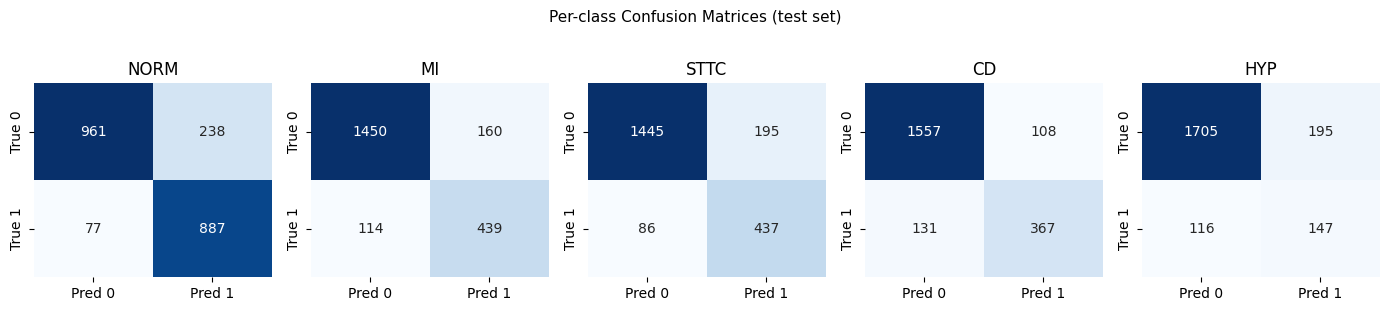

In [20]:
cms = multilabel_confusion_matrix(test_labels, test_preds)

fig, axes = plt.subplots(1, N_CLASSES, figsize=(14, 3))
for ax, superclass, cm in zip(axes, SUPERCLASSES, cms):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['True 0', 'True 1'],
                cbar=False)
    ax.set_title(superclass)

plt.suptitle('Per-class Confusion Matrices (test set)', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

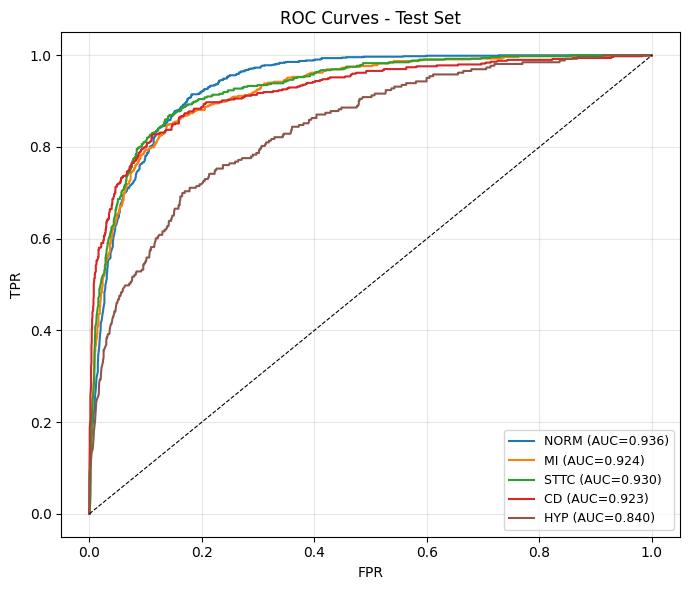

In [21]:
fig, ax = plt.subplots(figsize=(7, 6))
colors = plt.cm.tab10(np.linspace(0, 0.5, N_CLASSES))

for i, (superclass, color) in enumerate(zip(SUPERCLASSES, colors)):
    fpr, tpr, _ = roc_curve(test_labels[:, i], test_probs[:, i])
    auc = auc_per_class[i]
    ax.plot(fpr, tpr, lw=1.5, color=color, label=f'{superclass} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
ax.set(xlabel='FPR', ylabel='TPR', title='ROC Curves - Test Set')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Single-record Prediction And Bundle Save

In [22]:
@torch.no_grad()
def predict(wfdb_path: str, model: nn.Module, thresholds: np.ndarray, device=DEVICE) -> dict:
    sig, _ = wfdb.rdsamp(wfdb_path)
    sig = sig.astype(np.float32)
    sig = (sig - sig.mean(axis=0)) / (sig.std(axis=0) + 1e-8)
    sig = torch.tensor(sig.T.copy(), dtype=torch.float32).unsqueeze(0).to(device)

    model.eval()
    logits = model(sig).cpu().numpy()[0]
    probs = sigmoid_np(logits)
    preds = (probs >= thresholds).astype(int)

    return {
        'probabilities': dict(zip(SUPERCLASSES, probs.tolist())),
        'predictions': dict(zip(SUPERCLASSES, preds.tolist())),
        'labels': [superclass for superclass, pred in zip(SUPERCLASSES, preds) if pred],
    }


# Example:
# result = predict(os.path.join(DATA_DIR, 'records100/00000/00001_lr'), model, best_thresh)
# print(result)

In [23]:
bundle = {
    'state_dict': model.state_dict(),
    'thresholds': best_thresh,
    'superclasses': SUPERCLASSES,
    'lead_names': LEAD_NAMES,
    'adjacency': ADJ,
    'adjacency_norm': ADJ_NORM,
    'n_leads': N_LEADS,
    'n_classes': N_CLASSES,
    'sampling_rate': SAMPLING_RATE,
}
torch.save(bundle, 'ecg_stgnn_bundle.pt')
print('Bundle saved.')

# Reload sketch:
# bundle = torch.load('ecg_stgnn_bundle.pt', map_location='cpu')
# model = ECGSTGNN(bundle['adjacency_norm'], n_classes=bundle['n_classes'])
# model.load_state_dict(bundle['state_dict'])
# model.eval()

Bundle saved.
